# Compression Safeguards

[![Citation]](https://doi.org/10.5194/egusphere-egu26-9673)
[![Source]](https://github.com/juntyr/compression-safeguards)
[![Documentation]](https://compression-safeguards.readthedocs.io/en/latest/)

[Citation]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[Source]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[Documentation]: https://img.shields.io/badge/documentation-grey?style=for-the-badge&logo=readthedocs&logoColor=white

Compression Safeguards [^safeguards] are a user-centric framework that empowers users to (1) declare which properties they need lossy compression to preserve, and then (2) guarantees that these safety requirements are always preserved when (3) compressing with any user-chosen compressor. When wrapped in the appropriate safeguards, even unsafe compressors can be used safely.

During compression, the safeguards work by checking if the compressor-decompressed data would violate the user's safety requirements. If there are any violations, the safeguards produce pointwise corrections, which are then checked again. During decompression, these corrections are applied and ensure that the decompressed result satisfies all user safety requirements. Importantly, the corrections are are not just lossless encodings of the original data but are instead chosen to compress well.

The compression safeguards are implemented in the `compression-safeguards` Python package, with convenient user-facing frontends for a safeguarded meta-compressor in `numcodecs-safeguards` and chunked data in `xarray-safeguards`. These implementations can safeguard are variety of safety requirements, including regionally varying error bounds over the data $x$ and quantities of interest $f(x)$, missing values, and isosurfaces. The [documentation](https://compression-safeguards.readthedocs.io/en/latest/) provides several [examples](https://compression-safeguards.readthedocs.io/en/latest/examples/latent-heat-flux/) for inspiration, e.g. for preserving the relative vorticity derived from compressed u-v wind.

[^safeguards]: Tyree, J., Köhler, D., Underwood, R., Bouvier, C., Reichelt, T., Järvinen, H., & Klöwer, M. (2026). Compression Safeguards - Towards Safe and Fearless Lossy Compression of Earth System Data. *EGU General Assembly 2026*. Available from: [doi:10.5194/egusphere-egu26-9673](https://doi.org/10.5194/egusphere-egu26-9673).

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `SafeguardedCodec` meta-compressor

In [4]:
from numcodecs_safeguards import SafeguardedCodec
from numcodecs_zero import ZeroCodec

In [5]:
?SafeguardedCodec

Init signature:
SafeguardedCodec(
    *,
    codec: dict[str, None | int | float | str | bool | list['JSON'] | dict[str, 'JSON']] | numcodecs.abc.Codec,
    safeguards: collections.abc.Collection[dict[str, None | int | float | str | bool | list['JSON'] | dict[str, 'JSON']] | compression_safeguards.safeguards.abc.Safeguard],
    fixed_constants: collections.abc.Mapping[str | compression_safeguards.utils.bindings.Parameter, int | float | numpy.number | numpy.ndarray[tuple[int, ...], numpy.dtype[numpy.number]]] | compression_safeguards.utils.bindings.Bindings = <compression_safeguards.utils.bindings.Bindings object at 0x1163e19c0>,
    lossless: None | dict[str, None | int | float | str | bool | list['JSON'] | dict[str, 'JSON']] | numcodecs_safeguards.lossless.Lossless = None,
    compute: None | dict[str, None | int | float | str | bool | list['JSON'] | dict[str, 'JSON']] = None,
    _version: None | str | semver.version.Version = None,
) -> None
Docstring:     
An adaptor codec that use

## Bounding the pointwise absolute error

A pointwise absolute error bound can be guaranteed using the `eb` safeguard with type `abs`:

In [6]:
eb_abs = 0.1

SafeguardedCodec(
    codec=ZeroCodec(),  # for example, any numcodecs codec works
    safeguards=[
        {"kind": "eb", "type": "abs", "eb": eb_abs},
    ],
)

SafeguardedCodec(codec=ZeroCodec(), safeguards=[ErrorBoundSafeguard(type='abs', eb=0.1, equal_nan=False)], fixed_constants={}, lossless=Lossless(for_codec=None, for_corrections=PickBestCodec(CodecStack(TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))), CodecStack(BinaryDeltaCodec(), TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))))), compute=Compute(unstable_iterative=False, unstable_lossless_corrections=False))

## Bounding the pointwise relative error

A pointwise relative error bound can be guaranteed using the `eb` safeguard with type `rel`:

In [7]:
eb_rel = 0.01  # 1 %

SafeguardedCodec(
    codec=ZeroCodec(),  # for example, any numcodecs codec works
    safeguards=[
        {"kind": "eb", "type": "rel", "eb": eb_rel},
    ],
)

SafeguardedCodec(codec=ZeroCodec(), safeguards=[ErrorBoundSafeguard(type='rel', eb=0.01, equal_nan=False)], fixed_constants={}, lossless=Lossless(for_codec=None, for_corrections=PickBestCodec(CodecStack(TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))), CodecStack(BinaryDeltaCodec(), TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))))), compute=Compute(unstable_iterative=False, unstable_lossless_corrections=False))

## Bounding the pointwise ratio error

A pointwise ratio / logarithmic error bound can be guaranteed using the `eb` safeguard with type `ratio`:

In [8]:
eb_ratio = 1.01  # between x / 1.01 and x * 1.01

SafeguardedCodec(
    codec=ZeroCodec(),  # for example, any numcodecs codec works
    safeguards=[
        {"kind": "eb", "type": "ratio", "eb": eb_ratio},
    ],
)

SafeguardedCodec(codec=ZeroCodec(), safeguards=[ErrorBoundSafeguard(type='ratio', eb=1.01, equal_nan=False)], fixed_constants={}, lossless=Lossless(for_codec=None, for_corrections=PickBestCodec(CodecStack(TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))), CodecStack(BinaryDeltaCodec(), TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))))), compute=Compute(unstable_iterative=False, unstable_lossless_corrections=False))

## Preserving Missing Values

The error-bounding safeguards automatically preserve NaN missing values. By default, the exact NaN bit pattern is preserved. To only preserve whether a value is NaN but not its exact bit pattern, the error bounding safeguards accept a `equal_nan=True` option.

If the codec that is wrapped in safeguards raises an exception when the data includes NaN values, the `numcodecs_replace.ReplaceFilterCodec` can be used to first replace all NaN values, while leaving it up to the safeguards to reconstruct the NaN values during decompression:

In [9]:
from numcodecs_combinators.stack import CodecStack
from numcodecs_replace import Replacement, ReplaceFilterCodec

eb_abs = 0.1

SafeguardedCodec(
    # the replace filter codec must be used *inside* the safeguarded codec
    #  so that the safeguards see the NaN values in the original data and
    #  can reconstruct them during decompression
    codec=CodecStack(
        ReplaceFilterCodec(replacements={np.nan: "finite_mean"}),
        ZeroCodec(),  # for example, any numcodecs codec works
    ),
    safeguards=[
        {"kind": "eb", "type": "abs", "eb": eb_abs},
    ],
)

SafeguardedCodec(codec=CodecStack(ReplaceFilterCodec(replacements={nan: 'finite_mean'}), ZeroCodec()), safeguards=[ErrorBoundSafeguard(type='abs', eb=0.1, equal_nan=False)], fixed_constants={}, lossless=Lossless(for_codec=None, for_corrections=PickBestCodec(CodecStack(TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))), CodecStack(BinaryDeltaCodec(), TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))))), compute=Compute(unstable_iterative=False, unstable_lossless_corrections=False))

Missing values / other special values that use a different sentinel value than NaN can be preserved using the `same` safeguard, e.g. together with an absolute error bound:

In [10]:
eb_abs = 0.1

sentinel = 9999

SafeguardedCodec(
    codec=ZeroCodec(),  # for example, any numcodecs codec works
    safeguards=[
        {"kind": "eb", "type": "abs", "eb": eb_abs},
        {"kind": "same", "value": sentinel, "exclusive": True},
    ],
)

SafeguardedCodec(codec=ZeroCodec(), safeguards=[ErrorBoundSafeguard(type='abs', eb=0.1, equal_nan=False), SameValueSafeguard(value=9999, exclusive=True)], fixed_constants={}, lossless=Lossless(for_codec=None, for_corrections=PickBestCodec(CodecStack(TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))), CodecStack(BinaryDeltaCodec(), TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))))), compute=Compute(unstable_iterative=False, unstable_lossless_corrections=False))

The `exclusive` mode guarantees that every missing value in the input is still missing after decompression and that every non-missing value in the input stays non-missing after decompression.

## Preserving Quantities of Interest (QoI)

An error bound over a quantity of interest $f(x)$ can be guaranteed using the `qoi_eb_pw` (for pointwise QoIs) and `qoi_eb_stencil` (for moving window stencil QoIs) safeguards. For instance, preserving an absolute error bound over $x^2$ is as simple as:

In [11]:
eb_abs_qoi = 0.1

SafeguardedCodec(
    codec=ZeroCodec(),  # for example, any numcodecs codec works
    safeguards=[
        {"kind": "qoi_eb_pw", "qoi": "square(x)", "type": "abs", "eb": eb_abs_qoi},
    ],
)

SafeguardedCodec(codec=ZeroCodec(), safeguards=[PointwiseQuantityOfInterestErrorBoundSafeguard(qoi='square(x)', type='abs', eb=0.1, qoi_dtype='lossless')], fixed_constants={}, lossless=Lossless(for_codec=None, for_corrections=PickBestCodec(CodecStack(TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))), CodecStack(BinaryDeltaCodec(), TokenizeCodec(), BitmapIndexCodec(), TypedByteShuffleCodec(), FramedCodecStack(Zstd(level=3))))), compute=Compute(unstable_iterative=False, unstable_lossless_corrections=False))

## Preserving so much more

The compression safeguards can also be used to preserve isosurfaces, regions of interest, combinations of different safety requirements, topology via the local order of points in a neighbourhood [^topology], and so much more. Please see the [documentation](https://compression-safeguards.readthedocs.io/en/latest/) and [examples](https://compression-safeguards.readthedocs.io/en/latest/examples/latent-heat-flux/) for inspiration.

[^topology]: Inspired by: Fallin, A., Gorski, N., Agarwal, T., Wang, B., Gopalakrishnan, G., & Burtscher, M. (2026). Fast Topology-Aware Lossy Data Compression with Full Preservation of Critical Points and Local Order. *arXiv*. Available from: [doi:10.48550/arxiv.2603.26968](https://doi.org/10.48550/arxiv.2603.26968).

## Example

In [12]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [13]:
eb_abs = 0.1  # 0.1 K

codec = SafeguardedCodec(
    codec=ZeroCodec(),  # safeguards need to correct constant zero prediction
    safeguards=[
        # bound absolute error over the data
        {"kind": "eb", "type": "abs", "eb": eb_abs},
        # preserve global minimum and maximum
        {"kind": "sign", "offset": "$x_min"},
        {"kind": "sign", "offset": "$x_max"},
    ],
)

In [14]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

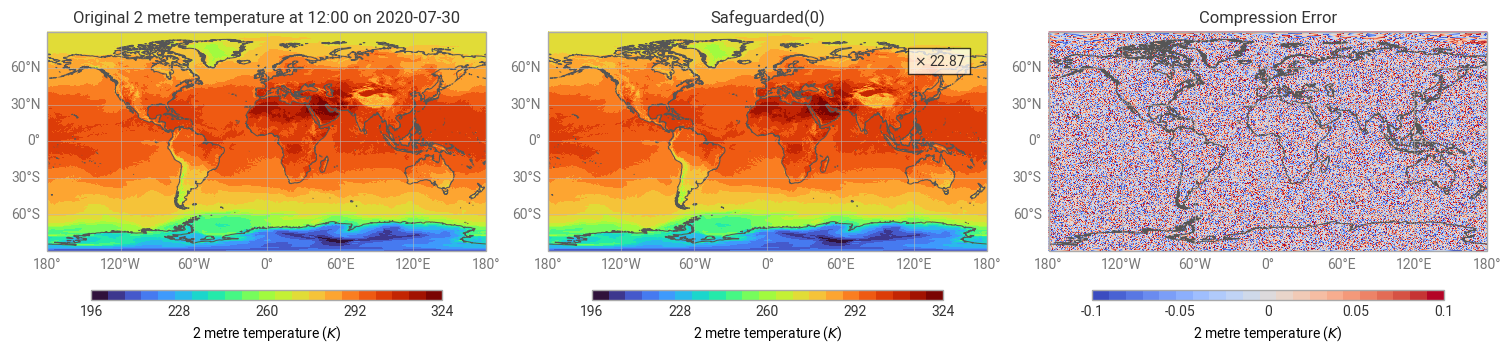

In [15]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title="Safeguarded(0)",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()

## Chunked Example

The Compression Safeguards can also be used to preserve safety requirements across chunk boundaries in chunked data using e.g. the `xarray-safeguards` package. For this example, we rechunk the data into chunks (mostly) of size 70x100 and then bound the relative error over the first-order second-order-accurate central difference along the periodic longitude axis.

In [16]:
da_chunked = da.chunk(lat=70, lon=100)
display(da_chunked.data)
da_chunked.dims

dask.array<xarray-<this-array>, shape=(2, 721, 1440), dtype=float64, chunksize=(2, 70, 100), chunktype=numpy.ndarray>

('time', 'lat', 'lon')

In [17]:
import xarray_safeguards

In [18]:
eb_rel_qoi = 0.01  # 1 %

safeguards = [
    {
        "kind": "qoi_eb_stencil",
        "qoi": """
            return finite_difference(
                x,                        # over the data
                order=1,                  # 1st order derivative
                accuracy=2,               # 2nd order accurate
                type=0,                   # central
                axis=-1,                  # longitude axis
                grid_centre=c["$d_lon"],  # coordinate, provided by xarray-safeguards
                grid_period=360,          # periodic over 360 degrees
            );
        """,
        "neighbourhood": [
            # periodic longitude axis, -1,+1 stencil for finite difference
            {"axis": -1, "before": 1, "after": 1, "boundary": "wrap"},
        ],
        "type": "rel",
        "eb": eb_rel_qoi,
    }
]

In [19]:
from numcodecs_combinators.stack import CodecStack

# lazily produce a prediction, i.e. the lossy decompressed data
da_prediction = CodecStack(
    ZeroCodec(),  # for example, any numcodecs codec works
).encode_decode_data_array(da_chunked)

In [20]:
# lazily produce the correction
da_correction = xarray_safeguards.produce_data_array_correction(
    data=da_chunked,
    prediction=da_prediction,
    safeguards=safeguards,
)

In [21]:
# lazily apply the correction, then compute the result
da_corrected = xarray_safeguards.apply_data_array_correction(
    prediction=da_prediction,
    correction=da_correction,
).compute()

In [22]:
# xarray-safeguards, like compression-safeguards, performs no lossless
# compression of the corrections, so use numcodecs-safeguards for that
import numcodecs_safeguards

da_correction_nbytes = np.array(
    numcodecs_safeguards.lossless._default_lossless_for_corrections().encode(
        da_correction.values
    )
).nbytes

In [23]:
def differentiate_along_longitude(da: xr.DataArray) -> xr.DataArray:
    da_wrapped = da.pad(lon=1, mode="wrap").assign_coords(
        lon=da.lon.pad(lon=1, mode="reflect", reflect_type="odd"),
    )

    da_dXdLon = da_wrapped.differentiate("lon")
    da_dXdLon.attrs.update(
        long_name=f"{da.long_name} derivative along longitude",
        units=f"{da.units} degree**-1",
    )

    return da_dXdLon.sel(lon=slice(da.lon.min(), da.lon.max()))

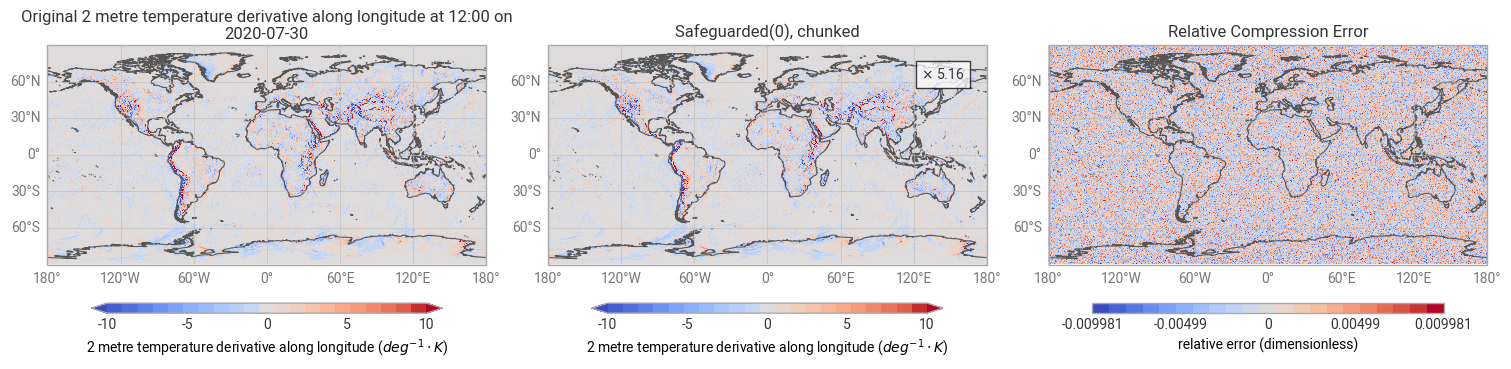

In [24]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

da_deriv = differentiate_along_longitude(da_chunked.compute())
da_corrected_deriv = differentiate_along_longitude(da_corrected.compute())

quickplot(
    da_deriv,
    fig.add_map(0, 0),
    title="Original {default_title}",
    error=True,
    vrange=(-10, 10),
)
quickplot(
    da_corrected_deriv,
    fig.add_map(0, 1),
    title="Safeguarded(0), chunked",
    cr=da.nbytes / da_correction_nbytes,
    error=True,
    vrange=(-10, 10),
)
quickplot(
    ((da_corrected_deriv - da_deriv) / da_deriv).assign_attrs(
        long_name="relative error", units="%"
    ),
    fig.add_map(0, 2),
    error=True,
    title="Relative Compression Error",
)

fig.show()